In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import sys
import os
from pyhessian import hessian
from reparamhessian import ReparamHessian as reparam_hessian

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../moritz2/bcd"))
sys.path.append(project_root)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)


from train_mlp import get_cifar_toy, muMLPTab9

from utils.mlp import MLP, Scale_Corrected_MLP
from trainer_mlp import MLPTrainer
from utils.param import get_bcd

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = "cuda"

dl = get_cifar_toy(device)

In [2]:
def train_epoch(model, loader, optimiser, loss_fn, device):
    model.train()
    losses_train, losses_adv, batch_sizes = [], [], []

    x, y = next(iter(loader))

    x, y = x.to(device), y.to(device)

    optimiser.zero_grad()
    loss_train = loss_fn(model(x), y)
    loss_train.backward()

    optimiser.step()
    losses_adv.append(None)
        
    losses_train.append(loss_train.item())
    batch_sizes.append(y.size(0))

    return losses_train, losses_adv, batch_sizes    

In [3]:
# using passed hyperparameters
WIDTH = 256
# LR = 0.001
LR = 0.01
RHO = 0
PARAMETERIZATION = 'mup' #'mup' | 'sp' | 'ntp'
PERTURBATION = 'naive' # 'mpp' | 'global' | 'gb' | 'naive'
BATCH_SIZE = 64
OPTIM_ALGO = 'SGD'
seed = 42
os.environ["CUDA_VISIBLE_DEVICES"] = "5"
DEVICE = "cuda"


EXP_NAME = 'test'

# Set hyperparameters
used_dataset = 'cifar10'

N_HIDDEN_LAYERS = 2
N_EPOCHS = 60

DIM_X = 32 * 32 * 3
DIM_Y = 1

# multipl_inout = [0.00390625, 32]
multipl_inout = [1, 1]

In [4]:
torch.manual_seed(0)
np.random.seed(0)

model = MLP(in_size=DIM_X,
            out_size=DIM_Y,
            hidden_size=WIDTH,
            n_hidden_layers=N_HIDDEN_LAYERS,
            parameterization=PARAMETERIZATION,
            perturbation=PERTURBATION,
            flat_indim = DIM_X,
            multipl_inout=multipl_inout,
            ll_zero_init=False,
            initvarnorm=False,
            multiplier_mup=False
            )
model.to(DEVICE)

trainer = MLPTrainer(
    model=model,
    train_dataloader=dl,
    eval_dataloader=dl,
    lr=LR,
    rho=RHO,
    optim_algo=OPTIM_ALGO,
    exp_name=EXP_NAME,
    device=DEVICE,
    classification=True,
    # loss_fn=loss_fn,
    # Optional extended evaluations:
    extended_eval_iter=0,  # Extended metrics every 100 batches
    eval_iter=100,  # Basic metrics every 50 batches
    save_best_file=False,
    save_final_file=f'test_hessian_scaling_{EXP_NAME}',
)

optimizer = trainer.optimizer

In [5]:
hessian_multipliers = []
layer_lrs = []
for p in optimizer.param_groups:
    print(p["lr"])
    hessian_multipliers.append(np.sqrt(p["lr"]))
    layer_lrs.append(p["lr"])

print(model)
print(hessian_multipliers)

2.56
0.01
3.90625e-05
MLP(
  (linear_1): Linear(in_features=3072, out_features=256, bias=False)
  (linear_2): Linear(in_features=256, out_features=256, bias=False)
  (linear_3): Linear(in_features=256, out_features=1, bias=False)
)
[np.float64(1.6), np.float64(0.1), np.float64(0.00625)]


In [6]:
# print weights
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data.mean())


linear_1.weight tensor(1.7756e-05, device='cuda:0')
linear_2.weight tensor(9.2436e-05, device='cuda:0')
linear_3.weight tensor(8.6972e-05, device='cuda:0')


In [7]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 2.56
    maximize: False
    momentum: 0
    name: layer0
    nesterov: False
    perturb: False
    rho: 0.0
    weight_decay: 0.0

Parameter Group 1
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    name: layer1
    nesterov: False
    perturb: False
    rho: 0.0
    weight_decay: 0.0

Parameter Group 2
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 3.90625e-05
    maximize: False
    momentum: 0
    name: layer2
    nesterov: False
    perturb: False
    rho: 0.0
    weight_decay: 0.0
)

In [8]:
from asdl import kernel_eigenvalues
epochs = 500

torch.manual_seed(0)
np.random.seed(0)

loss_fn = nn.MSELoss()
sharp_x, sharp_y = next(iter(dl))

# model = muMLPTab9(256, 1).to(device)
# optimizer = torch.optim.SGD(model.parameters(), lr=LR)

dfmulfree = pd.DataFrame(columns=["train", "adv", "batch_size", "reparam_eigen", "eigen", "grad_norm"])
print("Epoch\tLoss\tEigen\tEOS")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes = train_epoch(model, dl, optimizer, loss_fn, device)
    dfmulfree.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None, None, None]
    if epoch % 100 == 0 or epoch == 1:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        dfmulfree.loc[epoch, "eigen"] = top_eigenvalue
        
        reparam_hess = reparam_hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True, base_lr=LR, layer_lrs=layer_lrs)
        top_eigenvalue = reparam_hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        dfmulfree.loc[epoch, "reparam_eigen"] = top_eigenvalue

        print(f"{epoch}\t{losses_train[0]:.4f}\t{top_eigenvalue}\t{2/LR:.2f}")

Epoch	Loss	Eigen	EOS


/opt/common/envs/mup-abc/lib/python3.11/site-packages/torch/autograd/graph.py:823: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /pytorch/torch/csrc/autograd/engine.cpp:1260.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1	1.0063	1007.9437470297238	200.00
100	0.2846	233.07203712219442	200.00
200	0.1089	179.1373483750369	200.00
300	0.0202	96.59805977045954	200.00
400	0.0106	169.35545060045962	200.00
500	0.0065	188.6734667887858	200.00


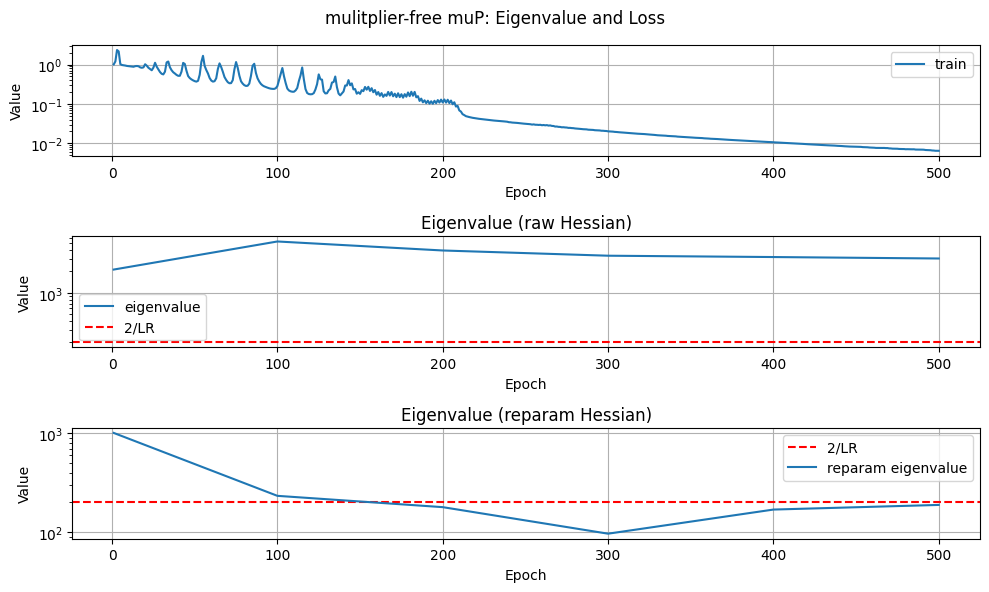

In [9]:
import matplotlib.pyplot as plt

def plot(df):
    fig, ax = plt.subplots(3, 1, figsize=(10, 6))   
    df["train"].plot(ax=ax[0], label="train")
    ax[0].set_yscale("log")
    df["eigen"].dropna().plot(ax=ax[1], label="eigenvalue")
    ax[1].axhline(2/LR, color="red", linestyle="--", label="2/LR")
    ax[2].axhline(2/LR, color="red", linestyle="--", label="2/LR")
    plt.suptitle("mulitplier-free muP: Eigenvalue and Loss")
    ax[1].set_title("Eigenvalue (raw Hessian)")
    ax[2].set_title("Eigenvalue (reparam Hessian)")
    df["reparam_eigen"].dropna().plot(ax=ax[2], label="reparam eigenvalue")
    for i in range(3):
        ax[i].set_xlabel("Epoch")
        ax[i].set_ylabel("Value")
        ax[i].legend()
        ax[i].grid()
        ax[i].set_yscale("log")
    plt.tight_layout()

plot(dfmulfree)

In [10]:
model = muMLPTab9(256, 1).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

dfmul = pd.DataFrame(columns=["train", "adv", "batch_size", "reparam_eigen", "eigen", "grad_norm"])
print("Epoch\tLoss\tEigen\tEOS")
for epoch in range(1, epochs + 1):
    losses_train, losses_adv, batch_sizes = train_epoch(model, dl, optimizer, loss_fn, device)
    dfmul.loc[epoch] = [losses_train[0], losses_adv[0], batch_sizes[0], None, None, None]
    if epoch % 100 == 0 or epoch == 1:
        hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True)
        top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        dfmul.loc[epoch, "eigen"] = top_eigenvalue
        
        reparam_hess = reparam_hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True, base_lr=LR, layer_lrs=layer_lrs)
        top_eigenvalue = reparam_hess.eigenvalues(maxIter=400, top_n=1)[0][0]
        dfmul.loc[epoch, "reparam_eigen"] = top_eigenvalue

        print(f"{epoch}\t{losses_train[0]:.4f}\t{top_eigenvalue}\t{2/LR:.2f}")

Epoch	Loss	Eigen	EOS
1	1.0010	71375.72074307734	200.00
100	0.2909	49424.191898402394	200.00
200	0.0492	45683.543165213305	200.00
300	0.0682	73151.9723127017	200.00
400	0.0165	34775.44869203074	200.00
500	0.0111	44327.87806304233	200.00


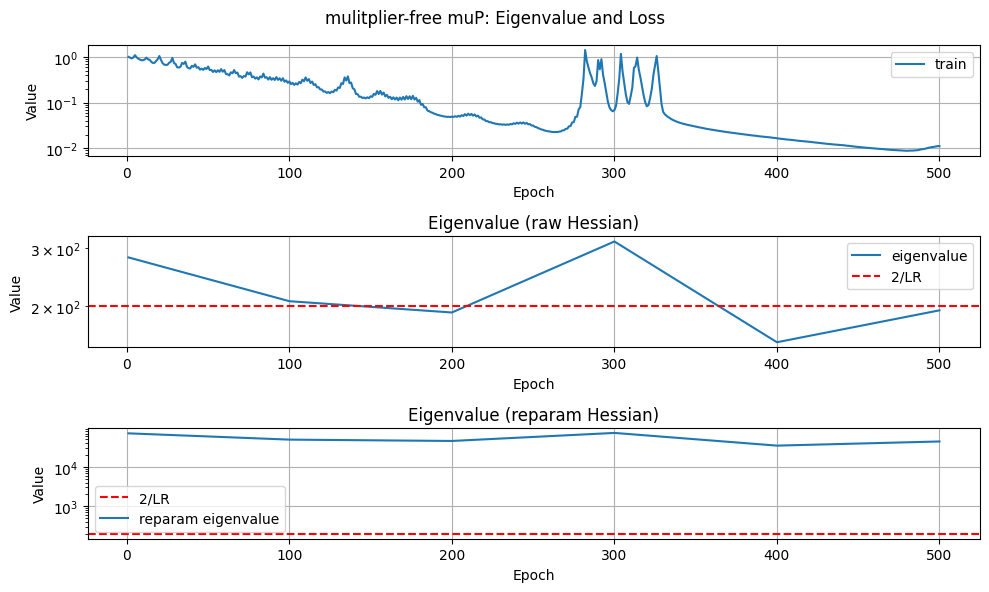

In [11]:
plot(dfmul)

In [37]:
layer_lrs

%load_ext autoreload
%autoreload 2

from train_mlp import get_cifar_toy, muMLPTab9

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
df = pd.DataFrame(columns=pd.MultiIndex.from_product([widths, ["raw", "reparam"]]))


In [48]:
epochs = 1000
widths = [64, 128, 256, 512, 1024]
LR = 0.002
loss_fn = nn.MSELoss()
sharp_x, sharp_y = next(iter(dl))

multiplier = True
print("Multiplier muP: ", multiplier)
for width in widths:
    print(f"Width: {width}")
    print("Epoch\tLoss\t\tEigen\t\tEOS\tGrad")
    torch.manual_seed(0)
    np.random.seed(0)
    # model = muMLPTab9(256, 1, multiplier=False).to(device)
    # optimizer = torch.optim.SGD(model.get_parameter_groups(learning_rate=LR, optimizer="SGD"))
    model = muMLPTab9(width, 1, multiplier=multiplier).to(device)
    # model.input_mult = 0.00390625
    # model.output_mult = 32
    # model.layer_scales = [1] * len(model.layer_scales)
    optimizer = torch.optim.SGD(model.get_parameter_groups(learning_rate=LR, optimizer="SGD"))

    for epoch in range(1, epochs + 1):

        model.train()

        x, y = next(iter(dl))

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        loss_train = loss_fn(model(x), y)
        loss_train.backward()
        grad_norm = torch.norm(torch.cat([p.grad.view(-1) for p in model.parameters()]))
        optimizer.step()
        
        losses_train = [loss_train.item()]
        top_eigenvalue = 2


        if epoch % 50 == 0 or epoch == 1:
            if multiplier:
                hess = hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True)
                top_eigenvalue = hess.eigenvalues(maxIter=400, top_n=1)[0][0]
                df.loc[epoch, (width, "raw")] = top_eigenvalue
            
            if not multiplier:
                reparam_hess = reparam_hessian(model, criterion=loss_fn, data=(sharp_x, sharp_y), cuda=True, base_lr=LR, layer_lrs=model.layer_lrs)
                top_eigenvalue = reparam_hess.eigenvalues(maxIter=400, top_n=1)[0][0]
                df.loc[epoch, (width, "reparam")] = top_eigenvalue
            
            print(f"{epoch}\t{losses_train[0]:.4f}\t\t{top_eigenvalue:.2f}\t\t{2/LR:.0f}\t{grad_norm:.2f}")

Multiplier muP:  True
Width: 64
Epoch	Loss		Eigen		EOS	Grad
1	1.0008		301.65		1000	4.24
50	0.4954		839.98		1000	14.57
100	0.2603		919.29		1000	8.28
150	0.1659		957.15		1000	6.78
200	0.1187		906.77		1000	7.29
250	0.0791		929.97		1000	6.25
300	0.0506		952.39		1000	4.68
350	0.0344		949.01		1000	3.56
400	0.0300		946.34		1000	4.38
450	0.0224		930.28		1000	3.70
500	0.0164		971.65		1000	2.92
550	0.0120		937.65		1000	2.10
600	0.0096		981.78		1000	1.90
650	0.0071		972.23		1000	1.05
700	0.0059		911.42		1000	0.39
750	0.0073		994.08		1000	2.42
800	0.0042		972.70		1000	0.80
850	0.0043		953.19		1000	1.32
900	0.0064		997.55		1000	2.78
950	0.0026		973.98		1000	0.51
1000	0.0050		1010.52		1000	2.43
Width: 128
Epoch	Loss		Eigen		EOS	Grad
1	1.0031		280.56		1000	4.69
50	0.4734		869.42		1000	13.87
100	0.2605		895.68		1000	9.90
150	0.1571		882.74		1000	7.08
200	0.1109		863.61		1000	7.36
250	0.0714		860.15		1000	5.58
300	0.0458		894.54		1000	4.12
350	0.0298		904.68		1000	2.64
400	0.0213		927.36		1000	2.09
450

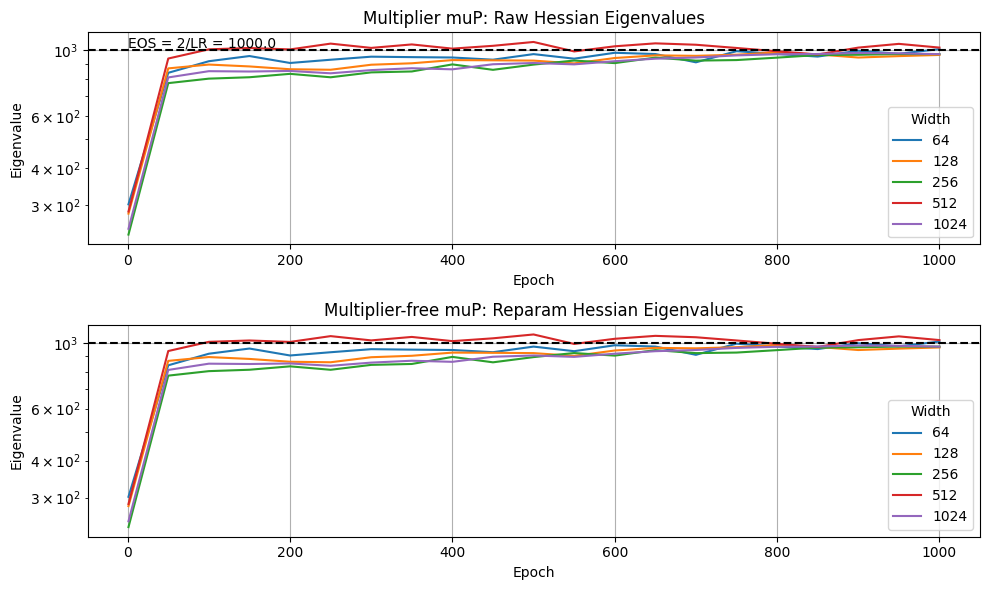

In [64]:
fig,ax = plt.subplots(2, 1, figsize=(10, 6))

df.xs("raw", axis=1, level=1).plot(title="Multiplier muP: Raw Hessian Eigenvalues", logy=True, ax=ax[0])
df.xs("reparam", axis=1, level=1).plot(title="Multiplier-free muP: Reparam Hessian Eigenvalues", logy=True, ax=ax[1])
ax[0].set_xlabel("Epoch")
ax[1].set_xlabel("Epoch")
ax[0].set_ylabel("Eigenvalue")
ax[1].set_ylabel("Eigenvalue")
ax[0].legend(title="Width")
ax[1].legend(title="Width")
ax[0].grid()
ax[1].grid()
ax[0].axhline(2/LR, color="black", linestyle="--", label="2/LR")
ax[1].axhline(2/LR, color="black", linestyle="--", label="2/LR")
ax[0].text(0, 2/LR, f"EOS = 2/LR = {2/LR}", color="black", fontsize=10, ha="left", va="bottom")
plt.tight_layout()


In [67]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def styled_hessian_plot(df, LR):
    # Font and layout
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "axes.titlesize": 15,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12
    })

    background_color = "#f0e8dd"
    grid_color = "#cccccc"
    eos_y = 2 / LR

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), facecolor=background_color)
    for a in ax:
        a.set_facecolor(background_color)

    df_raw = df.xs("raw", axis=1, level=1)
    df_reparam = df.xs("reparam", axis=1, level=1)

    df_raw.plot(logy=True, ax=ax[0], linewidth=2.2)
    df_reparam.plot(logy=True, ax=ax[1], linewidth=2.2)

    # Titles
    ax[0].set_title("Multiplier µP: Raw Hessian Eigenvalues", weight='bold', pad=10)
    ax[1].set_title("Multiplier-free µP: Reparam Hessian Eigenvalues", weight='bold', pad=10)

    # Axis labels
    for a in ax:
        a.set_xlabel("Epoch")
        a.set_ylabel("Eigenvalue")
        a.grid(True, which='both', linestyle='--', linewidth=0.6, color=grid_color, alpha=0.7)

    # Horizontal EOS line
    for a in ax:
        a.axhline(eos_y, color="black", linestyle="--", linewidth=1.2, label="2 / LR")
        a.text(0, eos_y, f"EOS = 2/LR = {eos_y:.2f}", color="black", fontsize=10, ha="left", va="bottom")

    ax[0].legend(title="Width", loc="best", frameon=False)
    ax[1].legend(title="Width", loc="best", frameon=False)

    plt.tight_layout()
    plt.show()


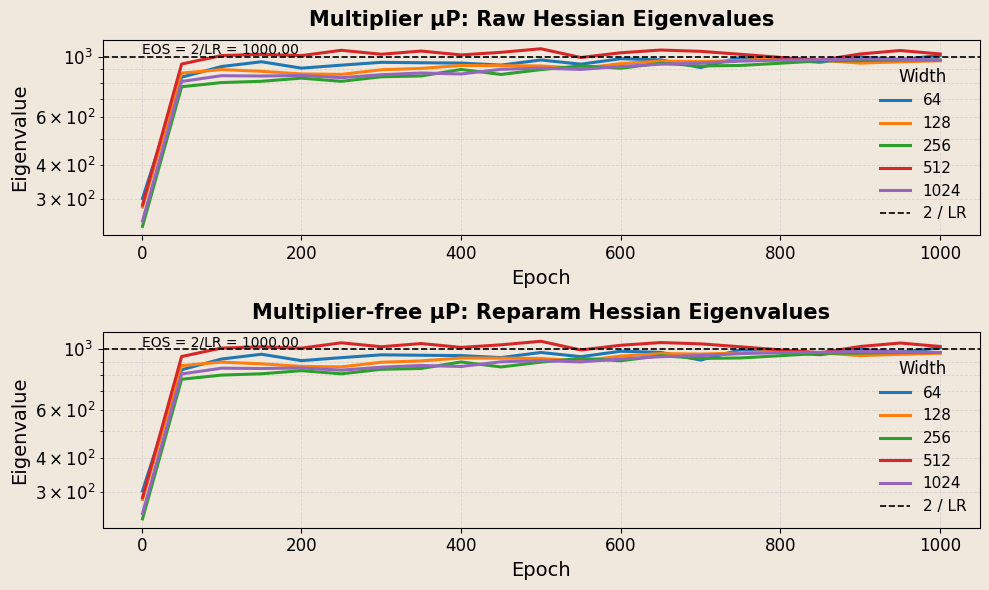

In [68]:
styled_hessian_plot(df, LR)

In [14]:
torch.manual_seed(0)
m_lr  = muMLPTab9(width, 1, multiplier=False).to(device)
print(m_lr.input_mult, m_lr.output_mult)
torch.manual_seed(0)
m_mul = muMLPTab9(width, 1, multiplier=True ).to(device)
print(m_mul.input_mult, m_mul.output_mult)
# m_mul.output_mult = 1
print(m_mul.input_mult, m_mul.output_mult)

opt_lr  = torch.optim.SGD(m_lr .get_parameter_groups(LR, "SGD"))
opt_mul = torch.optim.SGD(m_mul.get_parameter_groups(LR, "SGD"))

x, y = next(iter(dl))

def one_step(model, opt):
    opt.zero_grad()
    loss = F.mse_loss(model(x), y)
    loss.backward()
    return loss.item(), None , model

loss1, Δ1, model_lr = one_step(m_lr , opt_lr )
loss2, Δ2, model_mul = one_step(m_mul, opt_mul)

print("loss equal?  ", abs(loss1-loss2) < 1e-7)
# print("max update Δ ", (Δ1-Δ2).abs().max())


1.0 1.0
32.0 0.03125
32.0 0.03125
loss equal?   True


In [15]:
torch.manual_seed(0)
print("Learning rate scaled")
m_lr  = muMLPTab9(width, 1, multiplier=False).to(device)
print(m_lr.input_mult, m_lr.output_mult)
print(m_lr.layer_scales)
m_lr.get_parameter_groups(2, "SGD")
print("m_lr.layer_lrs", m_lr.layer_lrs)
torch.manual_seed(0)
print("\n\nMultiplier scaled")
m_mul = muMLPTab9(width, 1, multiplier=True ).to(device)
print(m_mul.input_mult, m_mul.output_mult)
print(m_mul.layer_scales)
m_mul.get_parameter_groups(2, "SGD")
print("m_mul.layer_lrs", m_mul.layer_lrs)
# m_mul.input_mult = 1
# m_mul.output_mult = 10
print("\n\n---")

with torch.no_grad():
    print("output_mult LR :", m_lr .output_mult)
    print("output_mult MUL:", m_mul.output_mult)

# do a new forward / backward for each network
for mdl, name in [(m_lr, "LR"), (m_mul, "MUL")]:
    mdl.zero_grad()
    out, act = mdl(x, record_activations=True)
    loss = F.mse_loss(out, y)
    print([act[0] for act in act])
    loss.backward(create_graph=True, retain_graph=True)
    print(f"{name}  ‖∇W3‖₂ =", mdl.fc_1.weight.grad.norm())
    print(f"{name}  ‖∇W3‖₂ =", mdl.fc_2.weight.grad.norm())
    print(f"{name}  ‖∇W3‖₂ =", mdl.fc_3.weight.grad.norm())

Learning rate scaled
1.0 1.0
[1024, 1, 0.0009765625]
m_lr.layer_lrs [2048, 2, 0.001953125]


Multiplier scaled
32.0 0.03125
[1, 1, 1]
m_mul.layer_lrs [2, 2, 2]


---
output_mult LR : 1.0
output_mult MUL: 0.03125
[tensor([ 0.5804, -0.6585,  1.3004,  ...,  0.7550, -0.2521,  0.7778],
       device='cuda:0', grad_fn=<SelectBackward0>), tensor([ 0.2954,  0.1784, -0.4545,  ...,  0.9465, -0.0160, -0.3488],
       device='cuda:0', grad_fn=<SelectBackward0>), tensor([-0.0121], device='cuda:0', grad_fn=<SelectBackward0>)]
LR  ‖∇W3‖₂ = tensor(0.1448, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
LR  ‖∇W3‖₂ = tensor(0.0718, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
LR  ‖∇W3‖₂ = tensor(1.9861, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
[tensor([ 0.5804, -0.6585,  1.3004,  ...,  0.7550, -0.2521,  0.7778],
       device='cuda:0', grad_fn=<SelectBackward0>), tensor([ 0.2954,  0.1784, -0.4545,  ...,  0.9465, -0.0160, -0.3488],
       device='cuda:0', grad_fn=<SelectBackwa

In [16]:
F.relu(m_lr.fc_1.weight.data @ x[0].flatten())

tensor([0.5804, 0.0000, 1.3004,  ..., 0.7550, 0.0000, 0.7778], device='cuda:0')

In [17]:
F.relu(m_mul.fc_1.weight.data @ x[0].flatten() * 64 ** 0.5)

tensor([0.1451, 0.0000, 0.3251,  ..., 0.1888, 0.0000, 0.1944], device='cuda:0')

In [18]:
F.relu(m_lr.fc_2.weight.data @ F.relu(m_lr.fc_1.weight.data @ x[0].flatten()))

tensor([0.2954, 0.1784, 0.0000,  ..., 0.9465, 0.0000, 0.0000], device='cuda:0')

In [19]:
F.relu(m_mul.fc_2.weight.data @ F.relu(m_mul.fc_1.weight.data @ x[0].flatten() * 64 ** 0.5))

tensor([0.0738, 0.0446, 0.0000,  ..., 0.2366, 0.0000, 0.0000], device='cuda:0')

In [20]:
m_lr.fc_3.weight.data @ F.relu(m_lr.fc_2.weight.data @ F.relu(m_lr.fc_1.weight.data @ x[0].flatten()))

tensor([-0.0121], device='cuda:0')

In [21]:
m_mul.fc_3.weight.data @ F.relu(m_mul.fc_2.weight.data @ F.relu(m_mul.fc_1.weight.data @ x[0].flatten() * 64 ** 0.5)) * 64 ** -0.5

tensor([-0.0121], device='cuda:0')

In [22]:
from torchviz import make_dot

torch.manual_seed(0)
print("Learning rate scaled")
m_lr  = muMLPTab9(width, 1, multiplier=False).to(device)

torch.manual_seed(0)
m_mul = muMLPTab9(width, 1, multiplier=True ).to(device)

out_lr = m_lr(x)
out_mul = m_mul(x)

loss_lr = F.mse_loss(out_lr, y)
loss_mul = F.mse_loss(out_mul, y)

loss_lr.backward(create_graph=True, retain_graph=True)
loss_mul.backward(create_graph=True, retain_graph=True)

make_dot(loss_lr, params=dict(model.named_parameters())).render("graphs/mulfree", format="png")
make_dot(loss_mul, params=dict(model.named_parameters())).render("graphs/mul", format="png")

m_lr.fc_2.weight.grad

Learning rate scaled


tensor([[ 1.4997e-05, -2.9448e-06, -4.4021e-05,  ..., -6.1967e-05,
         -3.6938e-06,  6.8366e-06],
        [ 1.4524e-04, -1.5370e-05, -1.8370e-06,  ..., -2.4351e-05,
          2.0985e-05,  7.9996e-05],
        [ 5.2001e-07,  0.0000e+00,  2.0781e-06,  ...,  7.4718e-07,
          0.0000e+00,  6.1378e-07],
        ...,
        [-3.6221e-04,  2.5212e-05, -2.8119e-04,  ..., -6.0160e-05,
         -3.3498e-05, -2.2185e-04],
        [-2.7813e-08,  1.5678e-09, -4.9748e-08,  ..., -3.6289e-08,
         -4.9402e-09, -2.2023e-08],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]], device='cuda:0', grad_fn=<CopyBackwards>)

In [23]:
20*(1/20)

1.0

In [24]:
torch.manual_seed(0)
fc = torch.nn.Linear(512, 10, bias=False)
x = torch.randn(64, 512, requires_grad=True)
out = 1/512 * fc(x*512)     # simulates output_mult
loss = out.norm()
loss.backward()
print(fc.weight.grad.norm())  # Scales with output_mult

tensor(24.4341, device='cuda:0')


In [25]:
for name, param in m_lr.named_parameters():
    print(name, param.grad.norm(), param.grad.mean())

fc_1.weight tensor(0.1448, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) tensor(1.6123e-06, device='cuda:0', grad_fn=<MeanBackward0>)
fc_2.weight tensor(0.0718, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) tensor(2.0632e-06, device='cuda:0', grad_fn=<MeanBackward0>)
fc_3.weight tensor(1.9861, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) tensor(-0.0246, device='cuda:0', grad_fn=<MeanBackward0>)


In [26]:
x = torch.randn(1, 10, requires_grad=True)
fc = torch.nn.Linear(10, 1)
output_mult = 10

out = output_mult * fc(x)
out.backward()

print(fc.weight.grad.norm())

tensor(27.8688, device='cuda:0')


In [27]:
for name, param in m_mul.named_parameters():
    print(name, param.grad.norm(), param.grad.mean())

fc_1.weight tensor(4.6323, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) tensor(5.1592e-05, device='cuda:0', grad_fn=<MeanBackward0>)
fc_2.weight tensor(0.0718, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) tensor(2.0632e-06, device='cuda:0', grad_fn=<MeanBackward0>)
fc_3.weight tensor(0.0621, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>) tensor(-0.0008, device='cuda:0', grad_fn=<MeanBackward0>)


In [28]:
print(model_mul.layer_lrs)
list(model_mul.parameters())[2].grad

[0.002, 0.002, 0.002]


tensor([[ 6.8311e-04,  2.6738e-03,  1.2923e-05,  ..., -2.7200e-03,
         -1.0605e-03,  0.0000e+00]], device='cuda:0')

In [29]:
print(model_lr.layer_lrs)
list(model_lr.parameters())[2].grad 

[2.048, 0.002, 1.953125e-06]


tensor([[ 0.0219,  0.0856,  0.0004,  ..., -0.0870, -0.0339,  0.0000]],
       device='cuda:0')

In [30]:
torch.manual_seed(0)
m_lr  = muMLPTab9(width, 1, multiplier=False).to(device)
torch.manual_seed(0)
m_mul = muMLPTab9(width, 1, multiplier=True ).to(device)

opt_lr  = torch.optim.SGD(m_lr .get_parameter_groups(0.01, "SGD"), momentum=0.0)
opt_mul = torch.optim.SGD(m_mul.get_parameter_groups(0.01, "SGD"), momentum=0.0)

x, y = next(iter(dl))

def one_step(model, opt):
    opt.zero_grad()
    loss = F.mse_loss(model(x), y)
    loss.backward()
    before = [p.clone() for p in model.parameters()]
    # opt.step()
    # delta  = torch.cat([(p-b).view(-1) for p, b in zip(model.parameters(), before)])
    return loss.item(), None

print(list(m_lr.parameters())[0][:5])
print(list(m_mul.parameters())[0][:20])

loss1, Δ1 = one_step(m_lr , opt_lr )
loss2, Δ2 = one_step(m_mul, opt_mul)



print("loss equal?   ", abs(loss1-loss2) < 1e-7)


tensor([[-8.6340e-03,  1.2794e-03,  4.1805e-03,  ...,  1.0408e-02,
          2.5557e-03,  1.9159e-02],
        [-1.8678e-05,  3.1859e-02, -1.0946e-02,  ..., -1.6611e-02,
          1.0867e-02, -2.4629e-02],
        [ 2.6298e-03,  5.3573e-03,  7.2955e-03,  ..., -8.5281e-03,
         -5.9275e-03, -8.6606e-04],
        [-2.2023e-02,  1.6706e-02,  2.2015e-02,  ...,  2.5764e-02,
         -1.6183e-02,  1.9989e-02],
        [-4.3765e-03, -7.2138e-03,  5.5655e-03,  ..., -1.5848e-02,
         -1.4410e-02,  1.5941e-02]], device='cuda:0', grad_fn=<SliceBackward0>)
tensor([[-2.6981e-04,  3.9982e-05,  1.3064e-04,  ...,  3.2526e-04,
          7.9867e-05,  5.9873e-04],
        [-5.8369e-07,  9.9558e-04, -3.4206e-04,  ..., -5.1910e-04,
          3.3958e-04, -7.6967e-04],
        [ 8.2182e-05,  1.6741e-04,  2.2799e-04,  ..., -2.6650e-04,
         -1.8523e-04, -2.7064e-05],
        ...,
        [ 9.4814e-04, -3.9486e-04, -2.6680e-04,  ..., -3.9056e-04,
         -6.3643e-05,  2.4678e-04],
        [ 1.0107

In [31]:
torch.manual_seed(0)
m_lr  = muMLPTab9(width, 1, multiplier=False).to(device)
torch.manual_seed(0)
m_mul = muMLPTab9(width, 1, multiplier=True ).to(device)

opt_lr  = torch.optim.SGD(m_lr .get_parameter_groups(0.01, "SGD"), momentum=0.0)
opt_mul = torch.optim.SGD(m_mul.get_parameter_groups(0.01, "SGD"), momentum=0.0)

x, y = next(iter(dl))

for step in range(3):
    for mdl,opt in [(m_lr,opt_lr),(m_mul,opt_mul)]:
        opt.zero_grad()
        F.mse_loss(mdl(x), y).backward()
        opt.step()

    # compare after each step
    diff = max( (p1-p2).abs().max()
                for p1,p2 in zip(m_lr.parameters(), m_mul.parameters()) )
    print(f"after step {step+1}  max |Δ| = {diff:.2e}")

after step 1  max |Δ| = 9.72e-02
after step 2  max |Δ| = 9.72e-02
after step 3  max |Δ| = 9.75e-02
